<a href="https://colab.research.google.com/github/sriram-dsl/computer-vision/blob/main/nano_DeiT/nano_DeiT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [17]:
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
import numpy as np
import matplotlib.pyplot as plt

# Device

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Variables

In [19]:
BATCH_SIZE = 12
IMG_SIZE = 28
PATCH_SIZE = 7
ATTENTION_HEADS = 4
TRANSFORMER_LAYERS = 4
EMBED_DIM = 16
CLASSES = 10
EPOCHS_STUDENT = 5
LR_STUDENT = 3e-4
CHANNELS = 3
TEMPERATURE = 2
ALPHA = 0.5

# Import Data

In [20]:
data_transformations = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t:t.repeat(3,1,1)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
    ])

train_ds = datasets.MNIST('./data', train=True, download=True, transform = data_transformations)
val_ds = datasets.MNIST('./data', train=False, download=True, transform = data_transformations)

# create Train and Val batches

In [21]:
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE)

# Teacher Model

In [22]:
teacher = models.resnet50(weights = models.ResNet50_Weights.IMAGENET1K_V2)
teacher.fc = nn.Linear(teacher.fc.in_features, CLASSES)
teacher.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# STUDENT ViT

In [23]:
class PatchEmbed(nn.Module) :
  def __init__(self, channels = CHANNELS, embed_dim = EMBED_DIM, patch_size = PATCH_SIZE, img_size = IMG_SIZE) :
    super().__init__()
    self.proj = nn.Conv2d(channels, embed_dim, patch_size, patch_size)
    self.n = (img_size // patch_size) ** 2

  def forward(self, x) :
    x = self.proj(x)
    x = x.flatten(2)
    x = x.transpose(1,2)
    return x


# Student ViT Class

In [24]:
class Vit(nn.Module) :
  def __init__(self, embed_dim = EMBED_DIM, attention_heads=ATTENTION_HEADS, layers=TRANSFORMER_LAYERS, classes = CLASSES) :
    super().__init__()
    self.patch_embed = PatchEmbed()
    self.cls = nn.Parameter(torch.zeros(1,1,embed_dim))
    self.distillation = nn.Parameter(torch.zeros(1,1,embed_dim))
    n = self.patch_embed.n
    self.position = nn.Parameter(torch.zeros(1, n+2, embed_dim))
    qkv_dim = embed_dim // attention_heads
    self.transformer_blocks = nn.Sequential(*[nn.TransformerEncoderLayer(embed_dim, attention_heads, qkv_dim, batch_first=True) for _ in range(layers)])
    self.layernorm = nn.LayerNorm(embed_dim)
    self.head_cls = nn.Linear(embed_dim, classes)
    self.head_distil = nn.Linear(embed_dim, classes)

  def forward(self, x) :
    B = x.shape[0]
    x = self.patch_embed(x)
    cls = self.cls.expand(B, -1, -1)
    dist = self.distillation.expand(B, -1, -1)
    x = torch.cat([cls, x, dist], 1) + self.position

    x = self.transformer_blocks(x)
    x = self.layernorm(x)

    cls_token = x[:, 0]
    distil_token = x[:, -1]

    cls_logits = self.head_cls(cls_token)
    distil_logits = self.head_distil(distil_token)

    return cls_logits, distil_logits


# Define Student Model

In [25]:
student = Vit().to(device)
opt_s = torch.optim.AdamW(student.parameters(), lr = LR_STUDENT)

In [28]:
def kd_loss(cls_logits, distil_logits, t_logits, y, temperature=TEMPERATURE, alpha=ALPHA) :
  kd = F.kl_div(F.log_softmax(distil_logits/temperature, dim=-1),
                F.softmax(t_logits/temperature, dim=-1), reduction='batchmean')

  ce = F.cross_entropy(cls_logits, y)
  return alpha * kd + (1-alpha) * ce

# Run Epochs

In [30]:
for e in range(EPOCHS_STUDENT) :
  student.train()
  for x,y in train_dl :
    x,y = x.to(device), y.to(device)
    with torch.no_grad() : t_logits = teacher(x)
    cls_logits, dist_logits = student(x)

    loss = kd_loss(cls_logits, dist_logits, t_logits, y)
    opt_s.zero_grad(); loss.backward(); opt_s.step()
  print(f"Ephochs : {e+1} Done")

Ephochs : 1 Done
Ephochs : 2 Done
Ephochs : 3 Done
Ephochs : 4 Done
Ephochs : 5 Done


In [31]:
student.eval()
correct, total = 0, 0
samples= []
with torch.no_grad() :
  for x,y in val_dl :
    x,y = x.to(device), y.to(device)
    cls_logits, dist_logits = student(x)
    cls_dist = (cls_logits + dist_logits) / 2
    pred = cls_dist.argmax(1)
    correct += (pred==y).sum().item(); total +=y.size(0)
    if len(samples) < 15 :
      samples.append((x.cpu(), pred.cpu(), y.cpu()))

acc = 100*correct/total
print(f"Test Accuracy : {acc:.2f}%")

Test Accuracy : 95.08%


### Displaying Predictions

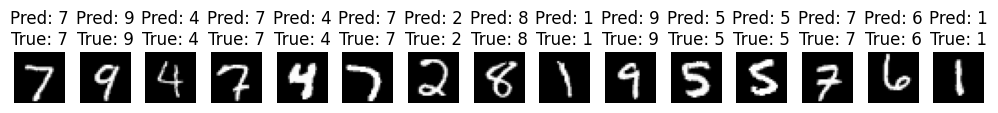

In [32]:
plt.figure(figsize=(10, 5))
for i, (image_batch, pred_batch, true_label_batch) in enumerate(samples):
    # Extract a single image, prediction, and true label from the batch
    image = image_batch[0]
    pred = pred_batch[0]
    true_label = true_label_batch[0]

    plt.subplot(1, len(samples), i + 1)
    # Now image is (C, H, W), so squeeze() does not change its shape
    # permute(1, 2, 0) correctly transforms (C, H, W) to (H, W, C) for imshow
    plt.imshow(image.squeeze().permute(1, 2, 0)) # Assuming 3 channels, if not adjust permute
    plt.title(f'Pred: {pred.item()}\nTrue: {true_label.item()}')
    plt.axis('off')
plt.tight_layout()
plt.show()